# Dueling DDQN - H1 threshold final version

변경 사항:
- `SENSITIVITY_FLOOR = 0.65
- Q-margin threshold는 validation H1 최대 기준으로 선택
- Grid search: `valid_tune`으로 checkpoint/threshold 탐색, `valid_select`로 하이퍼파라미터 선택
- 최종 학습: `valid_tune`으로 checkpoint/threshold 선택, `valid_select`는 최종 검증 비교용으로 사용
- `HIGH_RISK_PROB = 0.65`로 조정
- 보상: TN `+0.4`, FP `-0.8`, TP `+4.0`, FN `-6.0`
- 최종 학습 episode `600`
- `gamma=0.0`은 grid에 유지

추가 확인 사항:
- threshold 후보: `np.linspace(0.001, 0.999, 999)`로 촘촘하게 탐색
- tie-breaker: H1 → Sensitivity → G-mean → F1 → Precision → Specificity


In [2]:
# 랜덤성 제어를 위한 표준 라이브러리 모듈을 불러옵니다.
import random
from collections import deque
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import MinMaxScaler


# 데이터셋을 불러옵니다.
dat = pd.read_csv(Path("../../data/processed/data_selected.csv"), index_col=0)

# 재현 가능한 실험을 위해 시드 값을 고정합니다.
SEED = 1
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# High Risk 포함 윈도우 선택 확률을 하나의 전역 변수로 관리합니다.
# High Risk 윈도우 노출을 늘려 FN 감소 방향으로 조정합니다.
HIGH_RISK_PROB = 0.65

# GPU가 있으면 CUDA를, 없으면 CPU를 사용하도록 장치를 설정합니다.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# DDQN에서 사용할 Q-Network 구조를 정의합니다.
# 데이터 수가 많지 않으므로 과적합 가능성을 염두에 두고 2개 은닉층을 사용합니다.
class DuelingQNetwork(nn.Module):
    def __init__(self, state_dim: int, action_dim: int):
        super().__init__()

        # 공유 feature 추출 레이어
        # 논문과 동일한 96→64 구조 유지
        self.feature = nn.Sequential(

            nn.Linear(state_dim, 96),
            nn.ReLU(),
            nn.Linear(96, 64),
            nn.ReLU()
        )

        # Value stream: 상태 가치 V(s)
        self.value_stream = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)        # 스칼라 출력
        )

        # Advantage stream: 행동 우위 A(s,a)
        self.advantage_stream = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, action_dim)  # action_dim=2 출력
        )

    def forward(self, x):
        f = self.feature(x)

        v = self.value_stream(f)          # (batch, 1)
        a = self.advantage_stream(f)      # (batch, 2)

        # mean subtraction으로 identifiability 보장
        q = v + (a - a.mean(dim=1, keepdim=True))
        return q                          # (batch, 2)

# 경험을 저장하고 무작위 샘플링하기 위한 리플레이 버퍼를 정의합니다.
class ReplayBuffer:
    def __init__(self, capacity: int):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size: int):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = map(np.array, zip(*batch))
        return (
            torch.FloatTensor(states).to(device),
            torch.LongTensor(actions).unsqueeze(1).to(device),
            torch.FloatTensor(rewards).unsqueeze(1).to(device),
            torch.FloatTensor(next_states).to(device),
            torch.FloatTensor(dones.astype(np.float32)).unsqueeze(1).to(device),
        )

    def __len__(self):
        return len(self.buffer)


# DDQN 에이전트를 정의합니다.
class DDQNAgent:
    def __init__(
        self,
        state_dim,
        action_dim,
        gamma=0.95,
        lr=5e-4,
        batch_size=64,
        memory_size=100_000,
        target_update=2000,
        epsilon_start=1.0,
        epsilon_end=0.05,
        epsilon_decay=0.995,
    ):
        self.action_dim = action_dim
        self.gamma = gamma
        self.batch_size = batch_size
        self.target_update = target_update

        self.epsilon = epsilon_start
        self.epsilon_end = epsilon_end
        self.epsilon_decay = epsilon_decay

        self.online_net = DuelingQNetwork(state_dim, action_dim).to(device)
        self.target_net = DuelingQNetwork(state_dim, action_dim).to(device)
        self.target_net.load_state_dict(self.online_net.state_dict())
        self.target_net.eval()

        self.optimizer = optim.Adam(self.online_net.parameters(), lr=lr)
        self.memory = ReplayBuffer(memory_size)
        self.total_steps = 0

    def act(self, state, epsilon: float = None):
        if epsilon is None:
            epsilon = self.epsilon

        if random.random() < epsilon:
            return random.randrange(self.action_dim)

        state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
        with torch.no_grad():
            q_values = self.online_net(state_t)
        return int(torch.argmax(q_values, dim=1).item())

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_end, self.epsilon * self.epsilon_decay)

    def update(self):
        if len(self.memory) < self.batch_size:
            return None

        states, actions, rewards, next_states, dones = self.memory.sample(self.batch_size)
        
        #online_net에서 현재 Q값 계산
        q_values = self.online_net(states).gather(1, actions)
        #online_net에서 다음 행동 선택 
        next_actions = self.online_net(next_states).argmax(dim=1, keepdim=True)
        #target_net에서 다음 행동의 Q값 계산
        next_q_values = self.target_net(next_states).gather(1, next_actions)
        target_q = rewards + (1 - dones) * self.gamma * next_q_values
        loss = F.mse_loss(q_values, target_q.detach())
        
        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.online_net.parameters(), max_norm=10.0)
        self.optimizer.step()
        self.total_steps += 1
        if self.total_steps % self.target_update == 0:
            self.target_net.load_state_dict(self.online_net.state_dict())
        return float(loss.item())

def encode_risk_labels(series):
    s = series.copy()
    # 문자열 타입이면 'High Risk' → 1, 'Low Risk' → 0 매핑
    if pd.api.types.is_object_dtype(s) or pd.api.types.is_string_dtype(s):
        s = s.map({'Low Risk': 0, 'High Risk': 1})
        if s.isna().any():
            raise ValueError(f"알 수 없는 라벨 값이 있습니다: {series[s.isna()].unique()}")
    # 숫자형이면 그냥 int 변환
    return s.fillna(0).astype(int).to_numpy()

# ---- 데이터 준비 (Train/Valid/Test Split 먼저, 그 후 Scaling) ----

risk_label_col = "Risk_Label"
feature_cols = [c for c in dat.select_dtypes(include=[np.number]).columns if c != risk_label_col]
if len(feature_cols) == 0:
    raise ValueError("학습에 사용할 수치형 feature가 없습니다.")

risk_label_data = encode_risk_labels(dat[risk_label_col])
feature_data_raw = dat[feature_cols].fillna(0.0).to_numpy()
n_steps = len(dat)

train_ratio, valid_ratio, test_ratio = 0.45, 0.35, 0.2
n_train = int(n_steps * train_ratio)
n_valid = int(round(n_steps * valid_ratio))

train_indices = np.arange(0, n_train)
valid_indices = np.arange(n_train, n_train + n_valid)
test_indices = np.arange(n_train + n_valid, n_steps)

train_feature_raw = feature_data_raw[train_indices]
train_label = risk_label_data[train_indices]

valid_feature_raw = feature_data_raw[valid_indices]
valid_label = risk_label_data[valid_indices]
if len(valid_label) < 2:
    raise ValueError("Validation set 길이가 너무 짧아 tuning/selection 분할이 불가능합니다. split 비율을 조정하세요.")
valid_split_point = int(len(valid_label) * 0.65)
valid_tune_feature_raw = valid_feature_raw[:valid_split_point]
valid_tune_label = valid_label[:valid_split_point]
valid_select_feature_raw = valid_feature_raw[valid_split_point:]
valid_select_label = valid_label[valid_split_point:]

test_feature_raw = feature_data_raw[test_indices]
test_label = risk_label_data[test_indices]

def summarize_class_ratio(name, y):
    n_total = len(y)
    n0 = int((y == 0).sum())
    n1 = int((y == 1).sum())
    r0 = n0 / n_total if n_total > 0 else 0.0
    r1 = n1 / n_total if n_total > 0 else 0.0
    imbalance = (n1 / max(n0, 1)) if n_total > 0 else 0.0
    print(f"{name:>5} | n={n_total:4d} | class0={n0:4d} ({r0:.2%}) | class1={n1:4d} ({r1:.2%}) | c1/c0={imbalance:.4f})")
    if n0 == 0 or n1 == 0:
        raise ValueError(f"{name} set에 클래스 0 또는 1이 없습니다. split 비율 또는 기간을 조정하세요.")

print("Class Ratio Summary (Before ADASYN)")
summarize_class_ratio("Train", train_label)
summarize_class_ratio("ValTun", valid_tune_label)
summarize_class_ratio("ValSel", valid_select_label)
summarize_class_ratio("Test", test_label)

# 보상 계산에 사용할 class_ratio는 원본 train 기준으로 고정합니다.
n_negative_original = (train_label == 0).sum()
n_positive_original = (train_label == 1).sum()
class_ratio_reward = n_positive_original / max(n_negative_original, 1)
print(f"Reward class ratio (original train): {class_ratio_reward:.4f}")

# ---- ADASYN을 적용하지 않고 원본 학습 데이터를 그대로 사용 ----
train_feature = train_feature_raw.astype(np.float32)
train_label = train_label.astype(np.int64)

scaler = MinMaxScaler()
scaler.fit(train_feature)

train_feature = scaler.transform(train_feature).astype(np.float32)
valid_tune_feature = scaler.transform(valid_tune_feature_raw).astype(np.float32)
valid_select_feature = scaler.transform(valid_select_feature_raw).astype(np.float32)
test_feature = scaler.transform(test_feature_raw).astype(np.float32)

print("=" * 60)
print("Data Split Information")
print("=" * 60)
print(f"Total samples: {n_steps}")
print(f"Train set: {len(train_label)} samples")
print(f"  - Class 0: {(train_label==0).sum()}, Class 1: {(train_label==1).sum()}")
print(f"Valid(Tune) set: {len(valid_tune_label)} samples")
print(f"  - Class 0: {(valid_tune_label==0).sum()}, Class 1: {(valid_tune_label==1).sum()}")
print(f"Valid(Select) set: {len(valid_select_label)} samples")
print(f"  - Class 0: {(valid_select_label==0).sum()}, Class 1: {(valid_select_label==1).sum()}")
print(f"Test set: {len(test_indices)} samples ({test_ratio*100:.1f}%)")
print(f"  - Class 0: {(test_label==0).sum()}, Class 1: {(test_label==1).sum()}")

# 원본 학습 세트의 클래스 비율을 그대로 사용합니다.
n_negative = (train_label == 0).sum()
n_positive = (train_label == 1).sum()
class_ratio = class_ratio_reward

print(f"\nClass ratio (train set): {n_positive / max(n_negative, 1):.4f}")
print(f"Class ratio used for reward: {class_ratio:.4f}")
print("=" * 60)

state_dim = len(feature_cols)
action_dim = 2

def compute_reward(action, actual_label, class_ratio=None):
    action = int(action)
    actual_label = int(actual_label)

    # action: 0 = Low risk 예측, 1 = High risk 예측
    # actual_label: 0 = 실제 Low risk, 1 = 실제 High risk
    # 수정 방향:
    # - 현재 결과는 High risk를 너무 적게 예측해 FN이 많음
    # - FN 벌점을 크게 키우고 TP 보상도 강화
    # - FP 벌점은 낮춰 모델이 High risk 예측을 덜 회피하도록 조정
    # - 별도의 Sensitivity floor는 사용하지 않음
    if actual_label == 0 and action == 0:
        return 0.4      # TN
    elif actual_label == 0 and action == 1:
        return -0.8     # FP
    elif actual_label == 1 and action == 1:
        return 4.0      # TP
    elif actual_label == 1 and action == 0:
        return -6.0     # FN

# train_label에서 High Risk 인덱스를 미리 계산
high_risk_indices = np.where(train_label == 1)[0]
print(f"High Risk 인덱스 수 (train): {len(high_risk_indices)}")
print(f"HIGH_RISK_PROB: {HIGH_RISK_PROB}")

def get_balanced_start_idx(max_steps, high_risk_prob=None):
    """
    high_risk_prob 확률로 High Risk가 윈도우 안에
    반드시 포함되는 start_idx를 반환.
    
    나머지 확률로는 기존 랜덤 방식 사용.
    시계열 순서는 항상 유지됨.
    
    Parameters:
        max_steps: 에피소드 길이 (500)
        high_risk_prob: High Risk 포함 윈도우 선택 확률
    
    Returns:
        start_idx: 에피소드 시작 인덱스
    """
    if high_risk_prob is None:
        high_risk_prob = HIGH_RISK_PROB

    n = len(train_feature)
    max_start = n - max_steps - 1
    
    if np.random.random() < high_risk_prob:
        # High Risk 인덱스 중 하나를 무작위 선택
        hr_idx = np.random.choice(high_risk_indices)
        
        # 이 hr_idx가 윈도우 안에 포함되는
        # start_idx의 유효 범위 계산:
        # 조건: start_idx <= hr_idx <= start_idx + max_steps - 1
        # → low = hr_idx - max_steps + 1
        # → high = hr_idx
        low  = max(0, hr_idx - max_steps + 1)
        high = min(max_start, hr_idx)
        
        if low > high:
            # 유효 범위가 없으면 (데이터 끝부분 등) 랜덤
            return np.random.randint(0, max_start + 1)
        
        # 유효 범위 안에서 랜덤 선택
        # → High Risk가 윈도우 앞/중간/뒤 어디든 포함됨
        return int(np.random.randint(low, high + 1))
    
    else:
        # 기존 방식: 완전 랜덤
        return int(np.random.randint(0, max_start + 1))

Class Ratio Summary (Before ADASYN)
Train | n=1848 | class0=1638 (88.64%) | class1= 210 (11.36%) | c1/c0=0.1282)
ValTun | n= 934 | class0= 829 (88.76%) | class1= 105 (11.24%) | c1/c0=0.1267)
ValSel | n= 504 | class0= 427 (84.72%) | class1=  77 (15.28%) | c1/c0=0.1803)
 Test | n= 822 | class0= 723 (87.96%) | class1=  99 (12.04%) | c1/c0=0.1369)
Reward class ratio (original train): 0.1282
Data Split Information
Total samples: 4108
Train set: 1848 samples
  - Class 0: 1638, Class 1: 210
Valid(Tune) set: 934 samples
  - Class 0: 829, Class 1: 105
Valid(Select) set: 504 samples
  - Class 0: 427, Class 1: 77
Test set: 822 samples (20.0%)
  - Class 0: 723, Class 1: 99

Class ratio (train set): 0.1282
Class ratio used for reward: 0.1282
High Risk 인덱스 수 (train): 210
HIGH_RISK_PROB: 0.65



HYPERPARAMETER GRID SEARCH (Total: 72 combinations)

[1/72] gamma=0.00, lr=1e-04, eps_decay=0.995, bs=32
  Ep  20 | Tune H1: 0.4376 G-mean: 0.6579 F1: 0.3279 (Sens: 0.5714, Spec: 0.7575, Pre: 0.2299) | Th: 0.0373 | Best H1: 0.4411
  Ep  40 | Tune H1: 0.4585 G-mean: 0.5747 F1: 0.3814 (Sens: 0.3524, Spec: 0.9373, Pre: 0.4157) | Th: 1.6083 | Best H1: 0.4585
  Ep  60 | Tune H1: 0.4388 G-mean: 0.6418 F1: 0.3333 (Sens: 0.5143, Spec: 0.8010, Pre: 0.2466) | Th: 0.2367 | Best H1: 0.4585
  Ep  80 | Tune H1: 0.4376 G-mean: 0.5801 F1: 0.3514 (Sens: 0.3714, Spec: 0.9059, Pre: 0.3333) | Th: 0.7147 | Best H1: 0.4585
  Ep 100 | Tune H1: 0.4539 G-mean: 0.6139 F1: 0.3600 (Sens: 0.4286, Spec: 0.8794, Pre: 0.3103) | Th: 0.1113 | Best H1: 0.4585

[2/72] gamma=0.00, lr=1e-04, eps_decay=0.995, bs=64
  Ep  20 | Tune H1: 0.4297 G-mean: 0.6484 F1: 0.3213 (Sens: 0.5524, Spec: 0.7612, Pre: 0.2266) | Th: -0.0961 | Best H1: 0.4438
  Ep  40 | Tune H1: 0.4330 G-mean: 0.6327 F1: 0.3291 (Sens: 0.4952, Spec: 0.8082, Pr

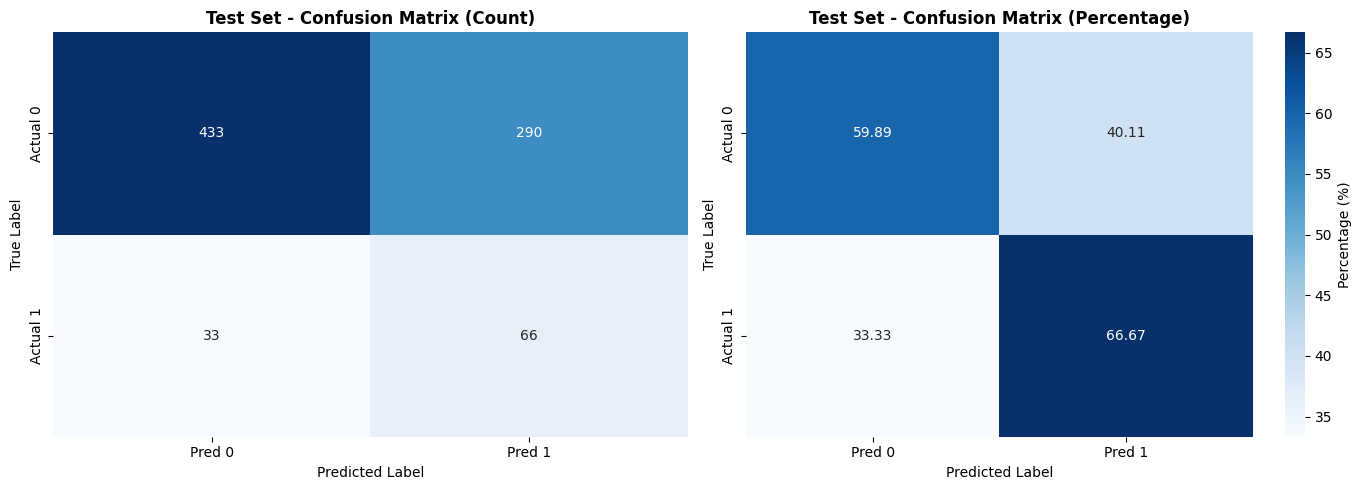


상세 메트릭 (Test Set):
Sensitivity (Recall for Class 1): 0.6667
Specificity (Recall for Class 0): 0.5989
Precision (Class 1):              0.1854
F1-Score:                         0.2901
G-mean:                           0.6319
H1 (G-mean & F1):                 0.3976

VALIDATION SET vs TEST SET 성능 비교

Validation(Selection) Set - H1: 0.4733, G-mean: 0.6581, Sens: 0.8182, Prec: 0.2386
Test Set - H1: 0.3976, G-mean: 0.6319, Sens: 0.6667, Prec: 0.1854
Difference H1 (Valid - Test): 0.0756

Validation Confusion Matrix:
[[226 201]
 [ 14  63]]

Test Confusion Matrix:
[[433 290]
 [ 33  66]]


In [3]:
# ---- Validation 기반 하이퍼파라미터 Grid Search + Q-margin Threshold 선택 ----
from itertools import product

# H1 기준 최종 튜닝: gamma=0.0도 포함하여 즉시보상 기준이 최적인지 함께 확인합니다.
param_grid = {
    "gamma": [0.0, 0.1, 0.3, 0.5, 0.8, 0.95],
    "lr": [1e-4, 3e-4, 5e-4],
    "epsilon_decay": [0.995, 0.997],
    "batch_size": [32, 64],
}


# H1 = F1과 G-mean의 조화평균
def compute_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0

    gmean = float(np.sqrt(sensitivity * specificity))
    f1 = float(2 * precision * sensitivity / (precision + sensitivity)) if (precision + sensitivity) > 0 else 0.0
    hm = float(2 * gmean * f1 / (gmean + f1)) if (gmean + f1) > 0 else 0.0

    return gmean, f1, hm, sensitivity, specificity, precision


def make_selection_key(hm, gmean, f1, precision, sensitivity, specificity):
    """
    최종 선택 기준:
    1순위 H1, 2순위 Sensitivity, 3순위 G-mean,
    4순위 F1, 5순위 Precision, 6순위 Specificity.
    민감도 floor는 사용하지 않고, 동률/근소 차이에서 FN 감소 방향을 우선합니다.
    """
    return (hm, sensitivity, gmean, f1, precision, specificity)


def predict_labels_argmax(model, features):
    preds = []
    model.eval()
    with torch.no_grad():
        for t in range(len(features)):
            state_t = torch.FloatTensor(features[t]).unsqueeze(0).to(device)
            q_values = model(state_t)
            preds.append(int(torch.argmax(q_values, dim=1).item()))
    return np.array(preds)


def evaluate_argmax(model, x_valid, y_valid):
    preds = predict_labels_argmax(model, x_valid)
    return compute_metrics(y_valid, preds)


def q_margin(model, features):
    """
    Q1 - Q0 값을 계산합니다.
    값이 클수록 High risk(action=1)를 더 선호한다는 의미입니다.
    """
    margins = []
    model.eval()
    with torch.no_grad():
        for i in range(len(features)):
            state_t = torch.FloatTensor(features[i]).unsqueeze(0).to(device)
            q_values = model(state_t).cpu().numpy().ravel()
            margins.append(q_values[1] - q_values[0])
    return np.array(margins)


def predict_by_threshold(model, features, threshold):
    margins = q_margin(model, features)
    return (margins >= threshold).astype(int)


def find_best_threshold_by_h1(model, features, labels):
    """
    valid set에서 Q-margin threshold를 선택합니다.
    선택 기준은 H1 최대이며, 민감도 floor는 사용하지 않습니다.
    """
    margins = q_margin(model, features)

    thresholds = np.unique(np.quantile(margins, np.linspace(0.001, 0.999, 999)))
    thresholds = np.r_[-np.inf, thresholds, np.inf]

    rows = []
    for th in thresholds:
        preds = (margins >= th).astype(int)
        gmean, f1, hm, sensitivity, specificity, precision = compute_metrics(labels, preds)
        rows.append({
            "threshold": th,
            "gmean": gmean,
            "f1": f1,
            "hm": hm,
            "sensitivity": sensitivity,
            "specificity": specificity,
            "precision": precision,
        })

    result_df = pd.DataFrame(rows)
    result_df = result_df.sort_values(
        by=["hm", "sensitivity", "gmean", "f1", "precision", "specificity"],
        ascending=[False, False, False, False, False, False]
    ).reset_index(drop=True)

    best = result_df.iloc[0]
    return float(best["threshold"]), best, result_df


def evaluate_with_threshold(model, features, labels, threshold):
    preds = predict_by_threshold(model, features, threshold)
    gmean, f1, hm, sensitivity, specificity, precision = compute_metrics(labels, preds)
    return gmean, f1, hm, sensitivity, specificity, precision, preds


# 그리드 서치 학습 =============================================
grid_search_results = []
param_combinations = list(product(*param_grid.values()))
param_names = list(param_grid.keys())

print("\n" + "=" * 80)
print(f"HYPERPARAMETER GRID SEARCH (Total: {len(param_combinations)} combinations)")
print("=" * 80)

patience = 12
min_episodes = 40
best_overall_select_key = (-1.0, -1.0, -1.0, -1.0, -1.0, -1.0)
best_overall_select_hm = -1.0
best_overall_params = None
best_overall_threshold = 0.0

for idx, params in enumerate(param_combinations):
    param_dict = dict(zip(param_names, params))
    gamma, lr, epsilon_decay, batch_size = params

    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)

    print(f"\n[{idx+1}/{len(param_combinations)}] gamma={gamma:.2f}, lr={lr:.0e}, eps_decay={epsilon_decay:.3f}, bs={batch_size}")

    agent_tune = DDQNAgent(
        state_dim=state_dim,
        action_dim=action_dim,
        gamma=gamma,
        lr=lr,
        batch_size=batch_size,
        memory_size=50_000,
        target_update=2000,
        epsilon_start=1.0,
        epsilon_end=0.05,
        epsilon_decay=epsilon_decay,
    )

    episodes_tune = 120
    max_steps_tune = 500
    best_tune_key = (-1.0, -1.0, -1.0, -1.0, -1.0, -1.0)
    best_tune_hm = -1.0
    best_tune_threshold = 0.0
    best_tune_state_dict = None
    patience_counter = 0

    for ep in range(1, episodes_tune + 1):
        start_idx = get_balanced_start_idx(max_steps_tune, high_risk_prob=HIGH_RISK_PROB)
        episode_reward = 0.0

        for i in range(max_steps_tune):
            state = train_feature[start_idx + i]
            next_state = train_feature[start_idx + i + 1] if start_idx + i + 1 < len(train_feature) else train_feature[start_idx + i]
            actual_label = train_label[start_idx + i]

            action = agent_tune.act(state)
            reward = compute_reward(action, actual_label, class_ratio)
            done = i == (max_steps_tune - 1)

            agent_tune.memory.push(state, action, reward, next_state, done)
            _ = agent_tune.update()
            episode_reward += reward

        agent_tune.decay_epsilon()

        # 5 에피소드마다 tune 데이터에서 Q-margin threshold까지 함께 선택합니다.
        if ep % 5 == 0:
            agent_tune.online_net.eval()
            tune_threshold, tune_info, _ = find_best_threshold_by_h1(
                agent_tune.online_net,
                valid_tune_feature,
                valid_tune_label,
            )

            tune_gmean = float(tune_info["gmean"])
            tune_f1 = float(tune_info["f1"])
            tune_hm = float(tune_info["hm"])
            tune_sensitivity = float(tune_info["sensitivity"])
            tune_specificity = float(tune_info["specificity"])
            tune_precision = float(tune_info["precision"])

            tune_key = make_selection_key(tune_hm, tune_gmean, tune_f1, tune_precision, tune_sensitivity, tune_specificity)

            if tune_key > best_tune_key:
                best_tune_key = tune_key
                best_tune_hm = tune_hm
                best_tune_threshold = tune_threshold
                patience_counter = 0
                best_tune_state_dict = {
                    k: v.detach().cpu().clone()
                    for k, v in agent_tune.online_net.state_dict().items()
                }
            else:
                patience_counter += 1

            if ep % 20 == 0:
                print(
                    f"  Ep {ep:3d} | Tune H1: {tune_hm:.4f} "
                    f"G-mean: {tune_gmean:.4f} F1: {tune_f1:.4f} "
                    f"(Sens: {tune_sensitivity:.4f}, Spec: {tune_specificity:.4f}, Pre: {tune_precision:.4f}) "
                    f"| Th: {tune_threshold:.4f} | Best H1: {best_tune_hm:.4f}"
                )

            if ep > min_episodes and patience_counter >= patience:
                break

    agent_tune.online_net.eval()
    if best_tune_state_dict is not None:
        agent_tune.online_net.load_state_dict(best_tune_state_dict)
        agent_tune.target_net.load_state_dict(best_tune_state_dict)

    # 복원된 checkpoint 기준으로 tune threshold를 다시 계산합니다.
    best_tune_threshold, tune_info_final, _ = find_best_threshold_by_h1(
        agent_tune.online_net,
        valid_tune_feature,
        valid_tune_label,
            )

    select_gmean, select_f1, select_hm, select_sensitivity, select_specificity, select_precision, _ = evaluate_with_threshold(
        agent_tune.online_net,
        valid_select_feature,
        valid_select_label,
        threshold=best_tune_threshold,
    )

    select_key = make_selection_key(select_hm, select_gmean, select_f1, select_precision, select_sensitivity, select_specificity)

    grid_search_results.append({
        "params": param_dict,
        "threshold_from_tune": best_tune_threshold,
        "best_tune_hm": best_tune_hm,
        "select_key": select_key,
        "select_gmean": select_gmean,
        "select_f1": select_f1,
        "select_hm": select_hm,
        "select_sensitivity": select_sensitivity,
        "select_specificity": select_specificity,
        "select_precision": select_precision,
    })

    if select_key > best_overall_select_key:
        best_overall_select_key = select_key
        best_overall_select_hm = select_hm
        best_overall_params = param_dict
        best_overall_threshold = best_tune_threshold

grid_search_results.sort(key=lambda x: x["select_key"], reverse=True)

print("\n" + "=" * 80)
print("TOP 5 HYPERPARAMETERS")
print("=" * 80)
for i, result in enumerate(grid_search_results[:5]):
    print(
        f"{i+1}. "
        f"H1: {result['select_hm']:.4f} | "
        f"G-mean: {result['select_gmean']:.4f} | "
        f"F1: {result['select_f1']:.4f} | "
        f"Sens: {result['select_sensitivity']:.4f} | "
        f"Spec: {result['select_specificity']:.4f} | "
        f"Prec: {result['select_precision']:.4f} | "
        f"Th: {result['threshold_from_tune']:.4f} | "
        f"Params: {result['params']}"
    )

if best_overall_params is None:
    raise RuntimeError("Grid search에서 best_overall_params를 찾지 못했습니다.")

print("\n" + "=" * 80)
print("BEST HYPERPARAMETERS")
print("=" * 80)
for k, v in best_overall_params.items():
    print(f"{k}: {v}")
print(f"Best Selection H1: {best_overall_select_hm:.4f}")
print(f"Threshold from tune: {best_overall_threshold:.6f}")
print("=" * 80)

# ---- 최적 파라미터로 본 학습 ----
print("\nTraining with best hyperparameters...")
agent = DDQNAgent(
    state_dim=state_dim,
    action_dim=action_dim,
    gamma=best_overall_params["gamma"],
    lr=best_overall_params["lr"],
    batch_size=best_overall_params["batch_size"],
    memory_size=50_000,
    target_update=2000,
    epsilon_start=1.0,
    epsilon_end=0.05,
    epsilon_decay=best_overall_params["epsilon_decay"],
)

episodes = 600
max_steps = 500
scores = []
valid_scores = []
best_ckpt_key = (-1.0, -1.0, -1.0, -1.0, -1.0, -1.0)
best_ckpt_valid_hm = -1.0
best_ckpt_epoch = 0
best_ckpt_threshold = 0.0
best_ckpt_state_dict = None

for ep in range(1, episodes + 1):
    episode_reward = 0.0
    start_idx = get_balanced_start_idx(max_steps, high_risk_prob=HIGH_RISK_PROB)

    for i in range(max_steps):
        state = train_feature[start_idx + i]
        next_state = train_feature[start_idx + i + 1] if start_idx + i + 1 < len(train_feature) else train_feature[start_idx + i]
        actual_label = train_label[start_idx + i]

        action = agent.act(state)
        reward = compute_reward(action, actual_label, class_ratio)
        done = i == (max_steps - 1)

        agent.memory.push(state, action, reward, next_state, done)
        _ = agent.update()
        episode_reward += reward

    agent.decay_epsilon()
    scores.append(episode_reward)

    # 최종 모델은 valid_tune에서 Q-margin threshold를 찾고, 그 기준으로 checkpoint를 저장합니다.
    if ep % 10 == 0:
        agent.online_net.eval()
        valid_threshold, valid_info, _ = find_best_threshold_by_h1(
            agent.online_net,
            valid_tune_feature,
            valid_tune_label,
            )

        valid_gmean = float(valid_info["gmean"])
        valid_f1 = float(valid_info["f1"])
        valid_hm = float(valid_info["hm"])
        valid_sensitivity = float(valid_info["sensitivity"])
        valid_specificity = float(valid_info["specificity"])
        valid_precision = float(valid_info["precision"])
        valid_scores.append(valid_hm)

        valid_key = make_selection_key(valid_hm, valid_gmean, valid_f1, valid_precision, valid_sensitivity, valid_specificity)

        if valid_key > best_ckpt_key:
            best_ckpt_key = valid_key
            best_ckpt_valid_hm = valid_hm
            best_ckpt_epoch = ep
            best_ckpt_threshold = valid_threshold
            best_ckpt_state_dict = {
                k: v.detach().cpu().clone()
                for k, v in agent.online_net.state_dict().items()
            }

        agent.online_net.train()

        print(
            f"Episode {ep:3d} | "
            f"Reward: {np.mean(scores[-10:]):8.5f} | "
            f"H1: {valid_hm:.4f} | "
            f"G-mean: {valid_gmean:.4f} | "
            f"F1: {valid_f1:.4f} | "
            f"Sens: {valid_sensitivity:.4f} | "
            f"Spec: {valid_specificity:.4f} | "
            f"Prec: {valid_precision:.4f} | "
            f"Th: {valid_threshold:.4f} | "
            f"Best H1: {best_ckpt_valid_hm:.4f}"
        )

print("최종 학습 완료")
if best_ckpt_state_dict is not None:
    agent.online_net.load_state_dict(best_ckpt_state_dict)
    agent.target_net.load_state_dict(best_ckpt_state_dict)
    print(
        f"Best checkpoint restored: epoch={best_ckpt_epoch}, "
        f"valid_h1={best_ckpt_valid_hm:.4f}, threshold={best_ckpt_threshold:.6f}"
    )
else:
    print("Warning: 저장된 checkpoint가 없어 마지막 모델을 사용합니다.")

agent.online_net.eval()

# ---- Test 평가: argmax가 아니라 valid_tune에서 고른 Q-margin threshold를 적용 ----
test_predictions = predict_by_threshold(
    agent.online_net,
    test_feature,
    threshold=best_ckpt_threshold,
)

cm_test = confusion_matrix(test_label, test_predictions, labels=[0, 1])
tn, fp, fn, tp = cm_test.ravel()
sensitivity_test = tp / (tp + fn) if (tp + fn) > 0 else 0.0
specificity_test = tn / (tn + fp) if (tn + fp) > 0 else 0.0
precision_test = tp / (tp + fp) if (tp + fp) > 0 else 0.0
gmean_test = float(np.sqrt(sensitivity_test * specificity_test))
f1_score_val = float(2 * precision_test * sensitivity_test / (precision_test + sensitivity_test)) if (precision_test + sensitivity_test) > 0 else 0.0
gmean_f1_hm = float(2 * gmean_test * f1_score_val / (gmean_test + f1_score_val)) if (gmean_test + f1_score_val) > 0 else 0.0

print("\n" + "=" * 60)
print("TEST SET - DDQN 분류 모델 최종 성능 평가")
print("=" * 60)
print(f"Q-margin threshold selected from valid_tune: {best_ckpt_threshold:.6f}")
print(f"\nG-mean: {gmean_test:.4f}")
print("\nConfusion Matrix:")
print(cm_test)
print(f"\nTN: {cm_test[0, 0]}, FP: {cm_test[0, 1]}")
print(f"FN: {cm_test[1, 0]}, TP: {cm_test[1, 1]}")

print("\n분류 리포트:")
print(classification_report(
    test_label,
    test_predictions,
    labels=[0, 1],
    target_names=["Class 0 (Negative)", "Class 1 (Positive)"],
    zero_division=0,
))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
sns.heatmap(
    cm_test,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    ax=ax1,
    xticklabels=["Pred 0", "Pred 1"],
    yticklabels=["Actual 0", "Actual 1"],
)
ax1.set_title("Test Set - Confusion Matrix (Count)", fontsize=12, fontweight="bold")
ax1.set_ylabel("True Label")
ax1.set_xlabel("Predicted Label")

cm_test_row_sums = cm_test.sum(axis=1, keepdims=True)
cm_test_percent = np.divide(
    cm_test.astype(float),
    cm_test_row_sums,
    out=np.zeros_like(cm_test, dtype=float),
    where=cm_test_row_sums != 0,
) * 100
ax2 = axes[1]
sns.heatmap(
    cm_test_percent,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    cbar=True,
    ax=ax2,
    xticklabels=["Pred 0", "Pred 1"],
    yticklabels=["Actual 0", "Actual 1"],
    cbar_kws={"label": "Percentage (%)"},
)
ax2.set_title("Test Set - Confusion Matrix (Percentage)", fontsize=12, fontweight="bold")
ax2.set_ylabel("True Label")
ax2.set_xlabel("Predicted Label")

plt.tight_layout()
plt.show()

print("\n상세 메트릭 (Test Set):")
print(f"Sensitivity (Recall for Class 1): {sensitivity_test:.4f}")
print(f"Specificity (Recall for Class 0): {specificity_test:.4f}")
print(f"Precision (Class 1):              {precision_test:.4f}")
print(f"F1-Score:                         {f1_score_val:.4f}")
print(f"G-mean:                           {gmean_test:.4f}")
print(f"H1 (G-mean & F1):                 {gmean_f1_hm:.4f}")
print("=" * 60)

print("\n" + "=" * 60)
print("VALIDATION SET vs TEST SET 성능 비교")
print("=" * 60)

valid_predictions = predict_by_threshold(
    agent.online_net,
    valid_select_feature,
    threshold=best_ckpt_threshold,
)
cm_valid = confusion_matrix(valid_select_label, valid_predictions, labels=[0, 1])
tn_v, fp_v, fn_v, tp_v = cm_valid.ravel()
sensitivity_valid = tp_v / (tp_v + fn_v) if (tp_v + fn_v) > 0 else 0.0
specificity_valid = tn_v / (tn_v + fp_v) if (tn_v + fp_v) > 0 else 0.0
precision_valid = tp_v / (tp_v + fp_v) if (tp_v + fp_v) > 0 else 0.0
gmean_valid = float(np.sqrt(sensitivity_valid * specificity_valid))
f1_valid = float(2 * precision_valid * sensitivity_valid / (precision_valid + sensitivity_valid)) if (precision_valid + sensitivity_valid) > 0 else 0.0
h1_valid = float(2 * gmean_valid * f1_valid / (gmean_valid + f1_valid)) if (gmean_valid + f1_valid) > 0 else 0.0

print(f"\nValidation(Selection) Set - H1: {h1_valid:.4f}, G-mean: {gmean_valid:.4f}, Sens: {sensitivity_valid:.4f}, Prec: {precision_valid:.4f}")
print(f"Test Set - H1: {gmean_f1_hm:.4f}, G-mean: {gmean_test:.4f}, Sens: {sensitivity_test:.4f}, Prec: {precision_test:.4f}")
print(f"Difference H1 (Valid - Test): {h1_valid - gmean_f1_hm:.4f}")
print("\nValidation Confusion Matrix:")
print(cm_valid)
print("\nTest Confusion Matrix:")
print(cm_test)
print("=" * 60)


In [5]:
# =========================
# 최종 Test 예측 결과 CSV 저장
# Date 컬럼 + DDQN 예측값 컬럼만 저장
# =========================
from pathlib import Path
import pandas as pd
import numpy as np

# 저장 경로
result_dir = Path(r"../../results/results_RL")
result_dir.mkdir(parents=True, exist_ok=True)

output_path = result_dir / "DDQN_test_predictions_final2.csv"

# Date 가져오기
# 1순위: dat 안에 Date 컬럼이 있는 경우
if "Date" in dat.columns:
    all_dates = dat["Date"].reset_index(drop=True)

# 2순위: dat의 index가 Date인 경우
else:
    all_dates = pd.Series(dat.index).reset_index(drop=True)

# test 구간 Date만 추출
test_dates = all_dates.iloc[test_indices].reset_index(drop=True)

# 날짜 형식 정리
test_dates = pd.to_datetime(test_dates, errors="coerce").dt.strftime("%Y-%m-%d")

# 예측 결과 저장용 데이터프레임
prediction_df = pd.DataFrame({
    "Date": test_dates,
    "DDQN_Prediction": np.asarray(test_predictions).astype(int)
})

# CSV 저장
prediction_df.to_csv(output_path, index=False, encoding="utf-8-sig")

print(f"저장 완료: {output_path}")
print(prediction_df.head())

저장 완료: ..\..\results\results_RL\DDQN_test_predictions_final2.csv
         Date  DDQN_Prediction
0  2022-10-17                0
1  2022-10-18                0
2  2022-10-19                1
3  2022-10-20                1
4  2022-10-21                0
